Material tests and fitted models

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

[0.    0.003 0.005 0.008 0.01  0.013 0.015 0.018 0.02  0.023 0.025 0.028
 0.03  0.033 0.035 0.038 0.04  0.043 0.045 0.048 0.05  0.053 0.055 0.058
 0.06  0.063 0.065 0.068 0.07  0.073 0.075 0.078 0.08  0.083 0.085 0.088
 0.09  0.093 0.095 0.098 0.1   0.103 0.105 0.108 0.11  0.113 0.115 0.118
 0.12  0.123 0.125 0.128 0.13  0.133 0.135 0.138 0.14  0.143 0.145 0.148
 0.15  0.153 0.155 0.158 0.16  0.163 0.165 0.168 0.17  0.173 0.175 0.178
 0.18  0.183 0.185 0.188 0.19  0.193 0.195 0.198 0.2   0.203 0.205 0.208
 0.21  0.213 0.215 0.218 0.22  0.223 0.225 0.228 0.23  0.233 0.235 0.238
 0.24  0.243 0.245 0.248]
[-0.0043  0.008   0.0563  0.0506  0.025   0.0149  0.0026  0.0118  0.0195
 -0.0169  0.0044  0.0149 -0.0095  0.0041 -0.0005  0.0042  0.0153 -0.014
  0.0078  0.0002 -0.0017  0.0184  0.0091 -0.0092 -0.0033 -0.0197  0.0081
  0.0075 -0.0098  0.0096 -0.003  -0.0047  0.0133 -0.0232 -0.0002 -0.0068
 -0.0077  0.0176  0.0102 -0.0008  0.0104 -0.0156 -0.0008  0.0038 -0.0141
  0.0052 -0.0024  0.003   

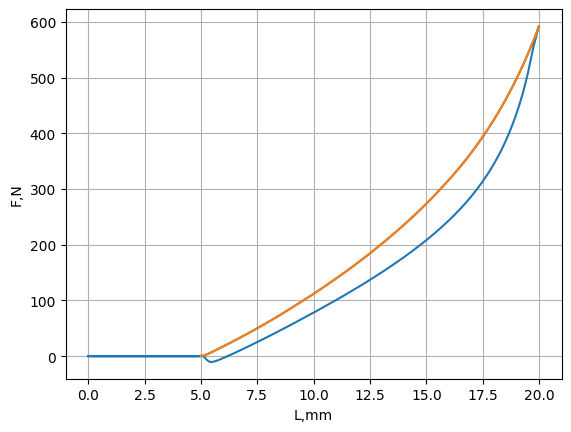

In [18]:
def read_data(filename):
    return np.loadtxt(
        filename,
        delimiter="\t",skiprows=3,
        converters=lambda x: float(x.replace(",", ".")))

c_data_1 = read_data("txtfiles/COMPR1.tab")
#c_data_2 = read_data("txtfiles/COMPR2.tab")
#c_data_3 = read_data("txtfiles/COMPR3.tab")

F1=c_data_1[:,0]
L1=c_data_1[:,1]
T1=c_data_1[:,2]


print(L1[0:100])
print(F1[0:100])


#F2 = c_data_2[:,0]
#L2=c_data_2[:,1]
#T2=c_data_2[:,2]

l1_min_pos = np.where(L1==5.0)[0][0]
#l2_min_pos = np.where(L2==5.0)[0][0]
l1max_pos = np.where(L1 == max(L1))[0][0]
#l2max_pos = np.where(L2 == max(L2))[0][0]

L1cut = L1[l1_min_pos:l1max_pos]
F1cut = F1[l1_min_pos:l1max_pos]

#L2cut = L2[l2_min_pos:l2max_pos]
#F2cut = F2[l2_min_pos:l2max_pos]

fig1,ax1 = plt.subplots()

ax1.plot(L1,F1)
ax1.plot(L1cut,F1cut)
#ax1.plot(L2,F2)

ax1.set_xlabel("L,mm")
ax1.set_ylabel("F,N")
ax1.grid()

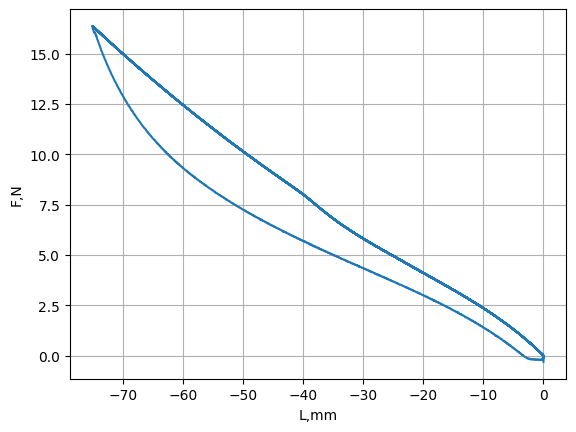

In [19]:
t_data_1 = read_data("txtfiles/TENS1.tab")
t_data_2 = read_data("txtfiles/TENS2.tab")
t_data_3 = read_data("txtfiles/TENS3.tab")

F1=t_data_1[:,0]
L1=t_data_1[:,1]
T1=t_data_1[:,2]

F2 = t_data_2[:,0]
L2=t_data_2[:,1]
T2=t_data_2[:,2]

"""
l1_min_pos = np.where(L1==5.0)[0][0]
l2_min_pos = np.where(L1==5.0)[0][0]
l1max_pos = np.where(L1 == max(L1))[0][0]
l2max_pos = np.where(L2 == max(L2))[0][0]

L1cut = L1[l1_min_pos:l1max_pos]
F1cut = F1[l1_min_pos:l1max_pos]

L2cut = L2[l2_min_pos:l2max_pos]
F2cut = F2[l2_min_pos:l2max_pos]
"""

fig1,ax1 = plt.subplots()

ax1.plot(L1,F1)
#ax1.plot(L2,F2)

ax1.set_xlabel("L,mm")
ax1.set_ylabel("F,N")
ax1.grid()

Dimless values

2000
8000


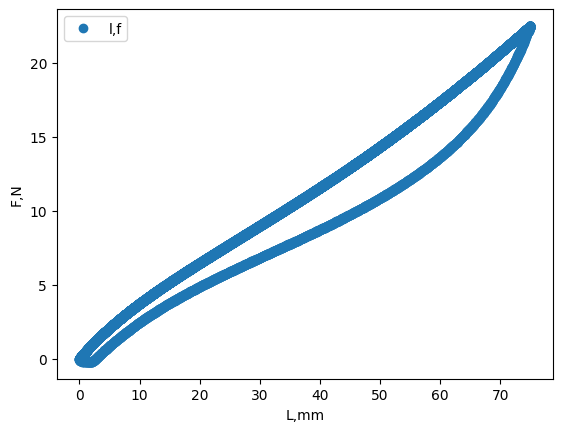

75.0


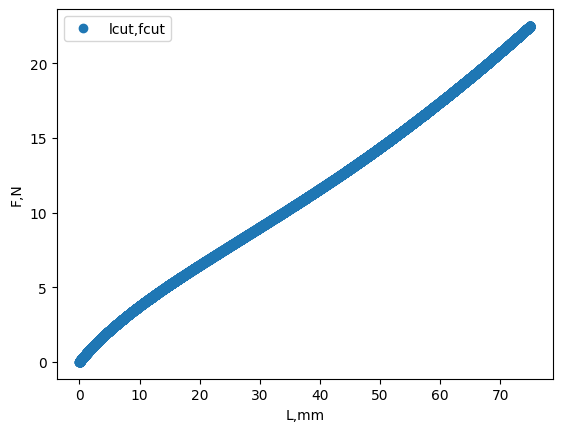

-0.0
-0.0021
exp data dimless: (array([1.        , 0.99990076, 0.9998346 , ..., 0.50403573, 0.50396957,
       0.50387033], shape=(6000,)), array([-0.00000000e+00,  2.44680386e+01, -1.70402412e+01, ...,
       -8.60840943e+05, -8.61240297e+05, -8.61617366e+05], shape=(6000,)))
exp data dimless: (array([1.     , 1.00012, 1.0002 , ..., 3.99976, 3.99984, 3.99992],
      shape=(35714,)), array([ 0.00000000e+00, -1.63291966e+01,  4.08229915e+02, ...,
        7.34555846e+05,  7.34418681e+05,  7.34666884e+05], shape=(35714,)))


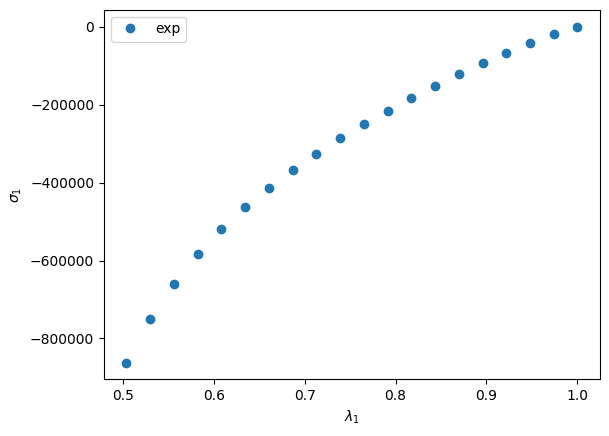

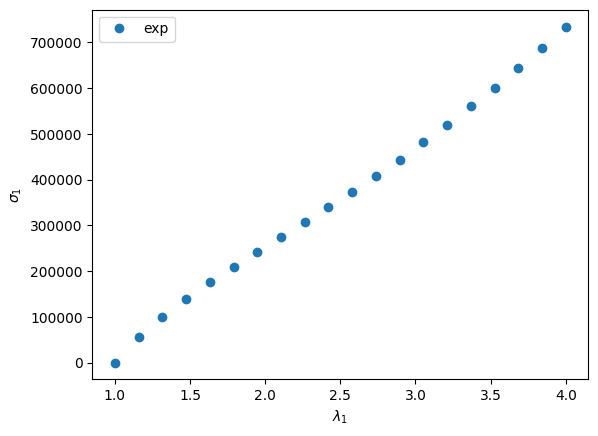

In [20]:
from pathlib import Path

BASE_DIR = Path.cwd()

def plot_data(data_exp, data_fit=None,exp_name="exp",xlabel=r"$\lambda_1$",ylabel=r"$\sigma_1$"):
    """
    Plot experimental and fitted uniaxial data.

    Parameters
    ----------
    data_exp : tuple
        (lambda1, sigma1) experimental data.

    data_fit : tuple
        (lambda1, sigma1) fitted data.
    """

    fig, ax = plt.subplots()

    ax.plot(data_exp[0],data_exp[1],"o",label=exp_name,)
    if(data_fit!=None):
        ax.plot(data_fit[0],data_fit[1],"-",linewidth=3,label="Fit",)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    plt.show()

def read_exp_data_compr(filename):
    data = np.loadtxt(filename,delimiter="\t",skiprows=3,
        converters=lambda x: float(x.replace(",", ".")))
    
    L=data[:,1]
    F=data[:,0]
    T=data[:,2]
    
    l_min_pos = np.where(L>=5.0)[0][0]
    l_max_pos = np.where(L==max(L))[0][0]

    print(l_min_pos)
    print(l_max_pos)

    Lcut = L[l_min_pos:l_max_pos]
    Fcut = F[l_min_pos:l_max_pos]
    Tcut = T[l_min_pos:l_max_pos]

    


    Lcut -= Lcut[0]
    Lcut /= 1000#mm to m
    
    Fcut -= Fcut[0]
    Tcut -= Tcut[0]

    Lcut = -Lcut
    Fcut = -Fcut

    #return np.column_stack((Lcut, Fcut, Tcut))
    return (Lcut,Fcut,Tcut)

def read_exp_data_tens(filename):
    data = np.loadtxt(filename,delimiter="\t",skiprows=3,
            converters=lambda x: float(x.replace(",", ".")))
    L=data[:,1]
    F=data[:,0]
    T=data[:,2]

    L = -L
    plot_data((L,F),exp_name="l,f",xlabel="L,mm",ylabel="F,N")

    print(L[np.where(L==max(L))[0][0]])
    l_max_pos = np.where(L==max(L))[0][0]

    Lcut = L[0:l_max_pos]
    Fcut = F[0:l_max_pos]
    Tcut = T[0:l_max_pos]

    plot_data((Lcut,Fcut),exp_name="lcut,fcut",xlabel="L,mm",ylabel="F,N")
    print(Lcut[0])
    print(Fcut[0])
    Lcut -= Lcut[0]
    Lcut /= 1000#mm to m
    Fcut -= Fcut[0]
    Tcut -= Tcut[0]

    

    return (Lcut,Fcut,Tcut)


def dimensioned_to_dimensionless(data,A0,L0):
    # L to lambda, lambda=L/L0
    # F to sigma, sigma=F/A0
    return (data[0]/L0+1,data[1]/A0)


def downsample(data, n):
    idx = np.linspace(0, len(data) - 1, n).astype(int)
    return data[idx]


A0CYLMEAN=686.61e-6#m^2
L0CYLMEAN=30.23e-3
A0RECTMEAN=30.62e-6
L0RECTMEAN=25.00e-3

filename1 = BASE_DIR / "txtfiles" / "COMPR1.tab"
filename2 = BASE_DIR / "txtfiles" / "TENS6.tab"

compr1_data = read_exp_data_compr(filename1)
tens1_data = read_exp_data_tens(filename2)



#print(f"exp data: {exp_data}")
compr1_data_dimless = dimensioned_to_dimensionless(compr1_data,A0CYLMEAN,L0CYLMEAN)
print(f"exp data dimless: {compr1_data_dimless}")




tens1_data_dimless = dimensioned_to_dimensionless(tens1_data,A0RECTMEAN,L0RECTMEAN)
print(f"exp data dimless: {tens1_data_dimless}")

compr1_data_dimless = (downsample(compr1_data_dimless[0],20),downsample(compr1_data_dimless[1],20))
tens1_data_dimless = (downsample(tens1_data_dimless[0],20),downsample(tens1_data_dimless[1],20))

plot_data(compr1_data_dimless)
plot_data(tens1_data_dimless)